# L13 worked example: a physics-informed network in JAX

**JAX** is a Python library for numerical computing that can differentiate any function you
write in it: https://docs.jax.dev. Lecture 11 used it for automatic differentiation; here we
also differentiate a network with respect to its **input**, which is what a PINN needs.

**Optax** is a library of optimizers for JAX, Adam among them:
https://optax.readthedocs.io. It turns gradients into parameter updates.

The problem: a mass on a spring with a damper, measured only during its first 0.36 s. We
train two networks on the same ten points. One sees only the data. The other, a
**physics-informed neural network (PINN)**, is also penalized whenever it breaks the equation
of motion. Then we ask both where the mass is after the data run out.

> Companion notes: [`notes.md`](notes.md).

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [ ]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "jax": "jax",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "optax": "optax",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


## 1. The spring-mass and its data

$$
m\,\frac{d^2x}{dt^2} + \mu\,\frac{dx}{dt} + k\,x = 0, \qquad x(0) = 1\ \text{m}, \quad \frac{dx}{dt}(0) = 0
$$

- $m = 1$ kg, $\mu = 4$ N·s/m, $k = 400$ N/m.
- `exact(t)` is the closed-form solution of the equation, used only to make the data and to
  score the models.
- `jax_enable_x64` makes JAX compute in 64-bit floats, so the second derivatives below are
  accurate.

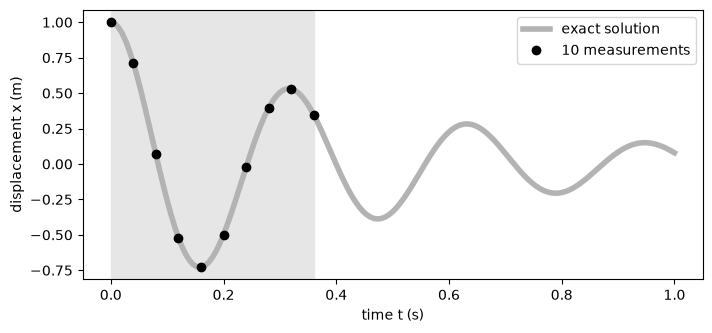

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

jax.config.update("jax_enable_x64", True)

m, mu, k = 1.0, 4.0, 400.0


def exact(t):
    d = mu / (2 * m)
    w = np.sqrt(k / m - d**2)
    return np.exp(-d * t) * (np.cos(w * t) + d / w * np.sin(w * t))


t_data = np.linspace(0, 0.36, 10)       # 10 measurements, first 0.36 s
x_data = exact(t_data)
t_phys = np.linspace(0, 1, 40)          # 40 collocation points, the whole second
t_plot = np.linspace(0, 1, 151)
x_true = exact(t_plot)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    t_plot,
    x_true,
    color="0.7",
    lw=4,
    label="exact solution",
)
ax.plot(t_data, x_data, "ko", label="10 measurements")
ax.axvspan(0, 0.36, color="0.9")
ax.set_xlabel("time t (s)")
ax.set_ylabel("displacement x (m)")
ax.legend()
plt.show()

## 2. A network, from scratch

- `init` makes the weights: one `(W, b)` pair per layer. $W$ has standard deviation
  $1/\sqrt{n_\text{in}}$, so each weighted sum has a spread near 1 and tanh starts in its linear
  range, not saturated (LeCun et al., *Efficient BackProp*, 1998).
- `net(params, t)` maps a vector of times to a vector of displacements through three hidden
  layers of 32 tanh units. tanh is smooth, so its second derivative exists, which the
  physics term needs.
- `x_nn(params, t)` is the same network for one scalar time, the form `jax.grad` needs.

In [3]:
def init(key, sizes):
    params = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        key, sub = jax.random.split(key)
        W = jax.random.normal(sub, (n_in, n_out)) * np.sqrt(1 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def net(params, t):
    h = t[:, None]
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return (h @ W + b)[:, 0]

def x_nn(params, t):
    return net(params, jnp.array([t]))[0]

params0 = init(jax.random.PRNGKey(0), [1, 32, 32, 32, 1])

In [4]:
print("weights and biases:", sum(W.size + b.size for W, b in params0))

weights and biases: 2209


## 3. Two losses

**The data loss** is the mean squared error over the ten measurements.

**The physics loss** is the mean squared residual of the equation at the 40 collocation
points, where we have no data:

$$
r(t_j) = m\,x_\text{NN}''(t_j) + \mu\,x_\text{NN}'(t_j) + k\,x_\text{NN}(t_j)
$$

- `jax.grad(f, argnums=1)` returns the derivative of `f` with respect to its second argument,
  the time. Applied twice it gives the second derivative.
- `jax.vmap` evaluates a function of one time at many times at once.
- The PINN loss is the data loss plus $\lambda = 10^{-4}$ times the physics loss. The residual
  is in newtons, hundreds of times larger than the displacement, so its weight is small.

In [5]:
dx = jax.grad(x_nn, argnums=1)      # dx/dt
ddx = jax.grad(dx, argnums=1)       # d2x/dt2

def residual(params, ts):
    x = jax.vmap(lambda t: x_nn(params, t))(ts)
    v = jax.vmap(lambda t: dx(params, t))(ts)
    a = jax.vmap(lambda t: ddx(params, t))(ts)
    return m * a + mu * v + k * x

def data_loss(params):
    return jnp.mean((net(params, jnp.array(t_data)) - x_data) ** 2)

def physics_loss(params):
    return jnp.mean(residual(params, jnp.array(t_phys)) ** 2)

lam = 1e-4

def pinn_loss(params):
    return data_loss(params) + lam * physics_loss(params)

In [6]:
residual0 = residual(params0, jnp.array([0.5]))[0]
print("residual of the untrained network at t = 0.5 s:", float(residual0))

residual of the untrained network at t = 0.5 s: -94.28226097449125


## 4. Train both with Adam

- `optax.adam(1e-3)` is the Adam optimizer with learning rate 0.001.
- `opt.update(grads, state, params)` turns the gradients into updates, and
  `optax.apply_updates` adds them to the parameters.
- `jax.jit` compiles one training step, so 30,000 steps take seconds (about 10 s for both
  networks).
- Both networks start from the same weights and get the same steps. Only the loss differs.

In [7]:
def train(loss, steps=30_000):
    opt = optax.adam(1e-3)
    params = params0
    state = opt.init(params)

    @jax.jit
    def step(params, state):
        grads = jax.grad(loss)(params)
        updates, state = opt.update(grads, state, params)
        return optax.apply_updates(params, updates), state

    for _ in range(steps):
        params, state = step(params, state)
    return params

p_nn = train(data_loss)
p_pinn = train(pinn_loss)

## 5. Compare after the data run out

RMSE is the root mean squared error against the exact solution, inside the data window and
after it.

                                 network      PINN
RMSE inside the data (m)          0.0067    0.0008
RMSE after the data (m)           0.5418    0.0010


network: residual RMS 163.0 N over the second, 165.39 N at the collocation points
PINN: residual RMS 5.3 N over the second, 0.70 N at the collocation points


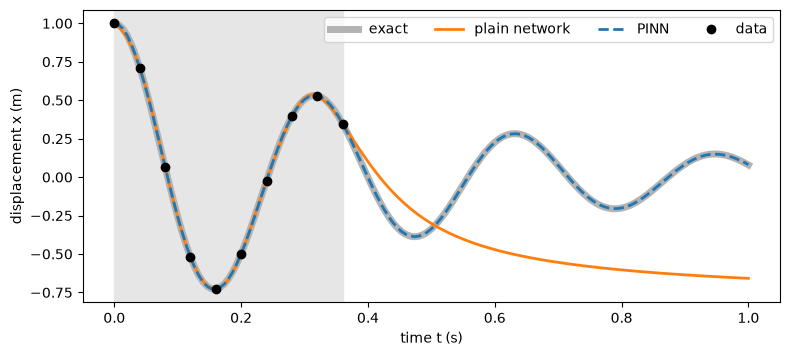

In [8]:
x_nn_plot = np.asarray(net(p_nn, jnp.array(t_plot)))
x_pinn_plot = np.asarray(net(p_pinn, jnp.array(t_plot)))
after = t_plot > t_data[-1]


def rmse(a, mask):
    return np.sqrt(np.mean((a[mask] - x_true[mask]) ** 2))


print(f"{'':30s}{'network':>10s}{'PINN':>10s}")
print(f"{'RMSE inside the data (m)':30s}{rmse(x_nn_plot, ~after):10.4f}{rmse(x_pinn_plot, ~after):10.4f}")
print(f"{'RMSE after the data (m)':30s}{rmse(x_nn_plot, after):10.4f}{rmse(x_pinn_plot, after):10.4f}")
for name, p in [("network", p_nn), ("PINN", p_pinn)]:
    grid = float(jnp.sqrt(jnp.mean(residual(p, jnp.array(t_plot)) ** 2)))
    colloc = float(jnp.sqrt(physics_loss(p)))
    print(f"{name}: residual RMS {grid:.1f} N over the second, {colloc:.2f} N at the collocation points")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axvspan(0, 0.36, color="0.9")
ax.plot(
    t_plot,
    x_true,
    color="0.7",
    lw=5,
    label="exact",
)
ax.plot(
    t_plot,
    x_nn_plot,
    color="C1",
    lw=2,
    label="plain network",
)
ax.plot(
    t_plot,
    x_pinn_plot,
    "C0--",
    lw=2,
    label="PINN",
)
ax.plot(t_data, x_data, "ko", label="data")
ax.set_xlabel("time t (s)")
ax.set_ylabel("displacement x (m)")
ax.legend(ncol=4)
plt.show()

**What to read in the output**

- Inside the data window both networks are close to the exact solution.
- After it, the plain network drifts to a flat line. The PINN follows the oscillation,
  because the equation tells it what happens next.
- The PINN's residual is small but **not zero**, and it is larger between the collocation
  points than at them. The physics is a penalty, applied only where you evaluate it.

## Try it

- Set `lam = 1e-2` and retrain. The residual shrinks. What happens to the fit to the data?
- Put the collocation points only inside the data window, `np.linspace(0, 0.36, 40)`. Can
  the PINN still extrapolate?
- Use 10 collocation points instead of 40, and compare the residual over the whole second.